In [90]:
import numpy as np

np.random.seed(42)

n_students = 100

midterm = np.clip(np.random.normal(70, 15, n_students), 0, 100)
final = np.clip(np.random.normal(75, 15, n_students), 0, 100)


In [91]:
assignments = np.clip(
    np.random.normal(80, 10, 500), 0, 100
).reshape(n_students, 5)

In [92]:
departments = np.random.choice(
    ['CS', 'EE', 'PHYS', 'CHEM', 'BIO'],
    size=n_students
)


In [93]:
def introduce_nan(arr, percent=0.05):
    n = int(len(arr) * percent)
    idx = np.random.choice(len(arr), n, replace=False)

    if arr.dtype.kind in {'U', 'S'}:
        arr = arr.astype(object)

    arr[idx] = np.nan
    return arr
midterm = introduce_nan(midterm)
final = introduce_nan(final)

for i in range(5):
    assignments[:, i] = introduce_nan(assignments[:, i])

departments = introduce_nan(departments)


In [94]:
import pandas as pd

df = pd.DataFrame({
    'StudentID': np.arange(1, n_students + 1),
    'Department': departments,
    'Midterm': midterm,
    'Final': final
})

for i in range(5):
    df[f'Assignment_{i+1}'] = assignments[:, i]

df.head(50)


,StudentID,Department,Midterm,Final,Assignment_1,Assignment_2,Assignment_3,Assignment_4,Assignment_5
0,1,BIO,77.450712,53.769439,83.577874,85.607845,NaN,90.538021,66.223306
1,2,CHEM,67.926035,68.690320,70.621750,85.150353,85.137860,85.150477,100.000000
2,3,PHYS,79.715328,69.859282,85.708905,91.355656,89.540018,86.513913,NaN
3,4,EE,92.845448,62.965841,87.589692,72.271748,77.631814,75.146365,80.818741
4,5,EE,66.487699,72.580714,100.000000,61.327348,86.862602,63.872841,75.280681
5,6,PHYS,66.487946,81.060763,90.889506,80.642800,69.222552,72.846963,86.795977
6,7,CHEM,93.688192,100.000000,72.696334,82.164586,80.455718,73.483997,100.000000
7,8,CHEM,81.511521,77.618667,86.339190,59.748574,81.864543,73.382135,88.524333
8,9,BIO,62.957884,78.863256,72.074793,78.852636,85.049873,88.657552,67.997036
9,10,BIO,78.138401,73.883311,76.654988,75.250547,73.466708,97.654542,84.049817


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     100 non-null    int64  
 1   Department    95 non-null     str    
 2   Midterm       95 non-null     float64
 3   Final         95 non-null     float64
 4   Assignment_1  95 non-null     float64
 5   Assignment_2  95 non-null     float64
 6   Assignment_3  95 non-null     float64
 7   Assignment_4  95 non-null     float64
 8   Assignment_5  95 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 7.2 KB


In [96]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])


In [97]:
df.head(50)

,StudentID,Department,Midterm,Final,Assignment_1,Assignment_2,Assignment_3,Assignment_4,Assignment_5
0,1,BIO,77.450712,53.769439,83.577874,85.607845,NaN,90.538021,66.223306
1,2,CHEM,67.926035,68.690320,70.621750,85.150353,85.137860,85.150477,100.000000
2,3,PHYS,79.715328,69.859282,85.708905,91.355656,89.540018,86.513913,NaN
3,4,EE,92.845448,62.965841,87.589692,72.271748,77.631814,75.146365,80.818741
4,5,EE,66.487699,72.580714,100.000000,61.327348,86.862602,63.872841,75.280681
5,6,PHYS,66.487946,81.060763,90.889506,80.642800,69.222552,72.846963,86.795977
6,7,CHEM,93.688192,100.000000,72.696334,82.164586,80.455718,73.483997,100.000000
7,8,CHEM,81.511521,77.618667,86.339190,59.748574,81.864543,73.382135,88.524333
8,9,BIO,62.957884,78.863256,72.074793,78.852636,85.049873,88.657552,67.997036
9,10,BIO,78.138401,73.883311,76.654988,75.250547,73.466708,97.654542,84.049817


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     100 non-null    int64  
 1   Department    100 non-null    str    
 2   Midterm       95 non-null     float64
 3   Final         95 non-null     float64
 4   Assignment_1  95 non-null     float64
 5   Assignment_2  95 non-null     float64
 6   Assignment_3  95 non-null     float64
 7   Assignment_4  95 non-null     float64
 8   Assignment_5  95 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 7.2 KB


In [99]:
numeric_cols = ['Midterm', 'Final'] + [f'Assignment_{i+1}' for i in range(5)]

df[numeric_cols] = df.groupby('Department')[numeric_cols].transform(
    lambda x: x.fillna(x.mean())
)


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     100 non-null    int64  
 1   Department    100 non-null    str    
 2   Midterm       100 non-null    float64
 3   Final         100 non-null    float64
 4   Assignment_1  100 non-null    float64
 5   Assignment_2  100 non-null    float64
 6   Assignment_3  100 non-null    float64
 7   Assignment_4  100 non-null    float64
 8   Assignment_5  100 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 7.2 KB


In [101]:
df.isna().sum()

StudentID       0
Department      0
Midterm         0
Final           0
Assignment_1    0
Assignment_2    0
Assignment_3    0
Assignment_4    0
Assignment_5    0
dtype: int64

In [102]:
df['Assignment_Avg'] = df[[f'Assignment_{i+1}' for i in range(5)]].mean(axis=1)

df['Total_Score'] = (
    0.25 * df['Midterm'] +
    0.25 * df['Final'] +
    0.50 * df['Assignment_Avg']
)


In [103]:
def grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Total_Score'].apply(grade)


In [104]:
summary = df.groupby('Department').agg(
    Avg_Total=('Total_Score', 'mean'),
    Std_Total=('Total_Score', 'std'),
    Avg_Midterm=('Midterm', 'mean'),
    Avg_Final=('Final', 'mean'),
    Student_Count=('StudentID', 'count')
)


In [105]:
import matplotlib.pyplot as plt


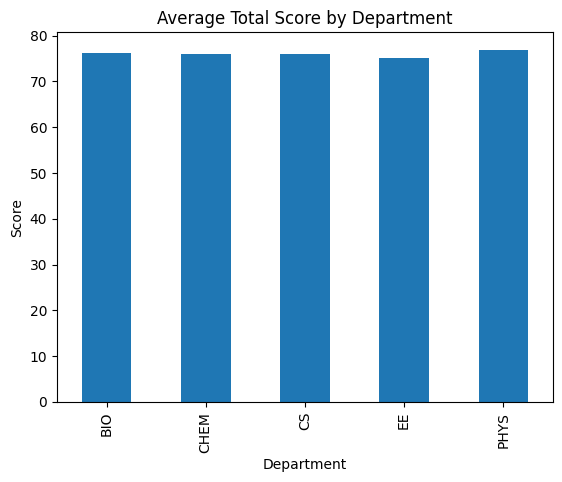

In [106]:
summary['Avg_Total'].plot(kind='bar')
plt.title('Average Total Score by Department')
plt.ylabel('Score')
plt.show()


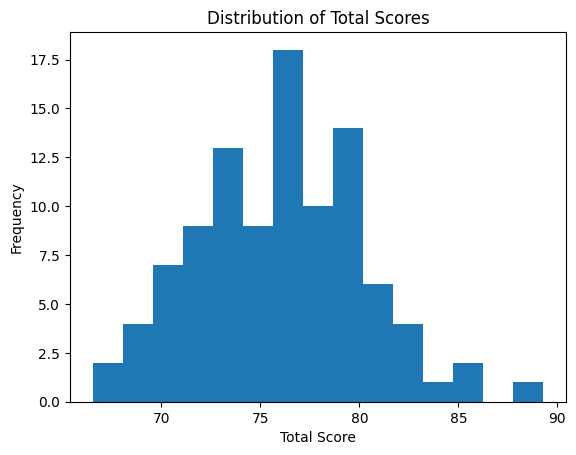

In [107]:
plt.hist(df['Total_Score'], bins=15)
plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()


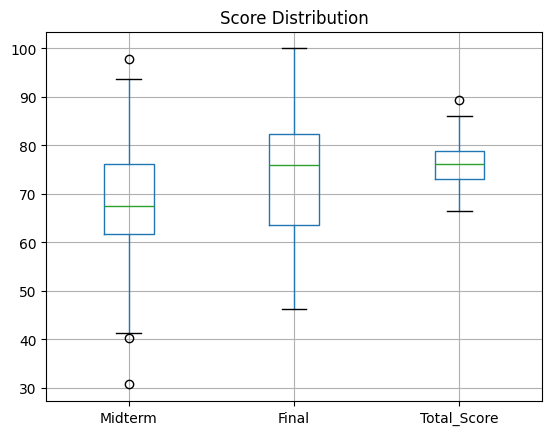

In [108]:
df[['Midterm', 'Final', 'Total_Score']].boxplot()
plt.title('Score Distribution')
plt.show()


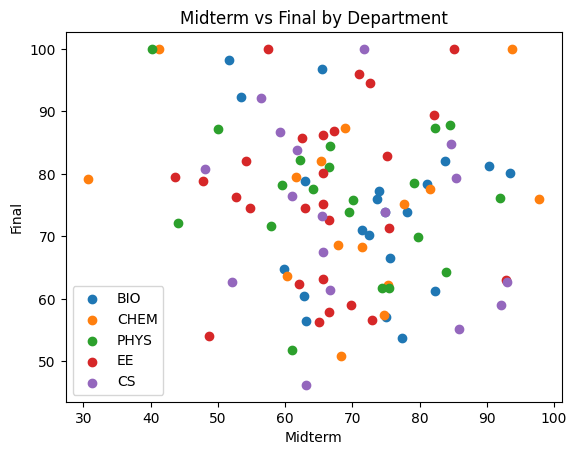

In [109]:
for dept in df['Department'].unique():
    subset = df[df['Department'] == dept]
    plt.scatter(subset['Midterm'], subset['Final'], label=dept)

plt.xlabel('Midterm')
plt.ylabel('Final')
plt.legend()
plt.title('Midterm vs Final by Department')
plt.show()


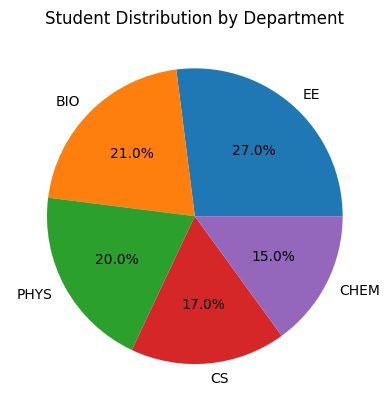

In [110]:
df['Department'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Student Distribution by Department')
plt.ylabel('')
plt.show()


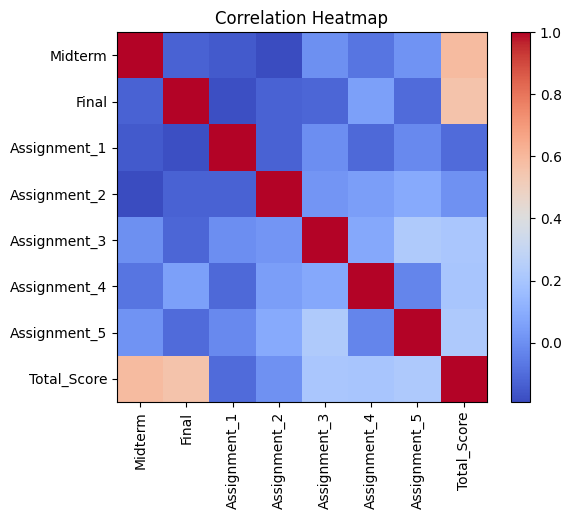

In [111]:
corr = df[numeric_cols + ['Total_Score']].corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


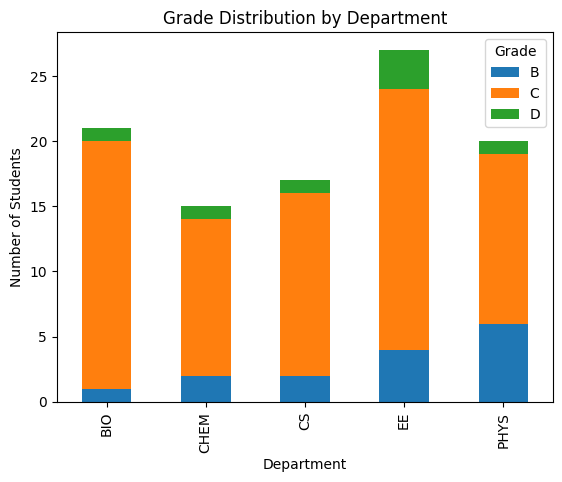

In [112]:
grade_dist = pd.crosstab(df['Department'], df['Grade'])
grade_dist.plot(kind='bar', stacked=True)
plt.title('Grade Distribution by Department')
plt.ylabel('Number of Students')
plt.show()
